---

<div align="center">

<h1 style="color:#345682; font-weight:bold;">
:השפעות רגשיות של מלחמת חרבות ברזל<br> ניתוח חוויות הורים וילדים
</h1>


<p style="font-size:16px;">
<b>Names of Students:</b><br>
Paz Ohayun<br>
Zack Netz<br>
Yamit Buskila
</p>
</div>

<a id='top'></a>
<div align="center">

<img src="https://github.com/yamitbuskila/exercises/blob/main/images/afbedd1d-11d9-4e6a-9789-e9c865b0e27e.png?raw=true" width="800"/>

</div>

---

<h2 style="color: #345682">Table of Contents:</h2>

<ol>
  <li>Data Preprocessing and Cleaning</li>
  <li>Getting to Know the Data</li>
  <li>Correlation Analysis</li>
  <li>Emotional Impact of Parental Soothing on Children</li>
  <li>Emotional Effects of Parental Self-Calming Strategies</li>
  <li>Emotional Impact of Parental News Consumption</li>
  <li>Appendices</li>
</ol>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from collections import Counter
from bidi.algorithm import get_display
import arabic_reshaper
from wordcloud import WordCloud
from collections import Counter
from IPython.display import display, HTML

In [7]:
df = pd.read_csv("new_data.csv") 
df.columns =df.columns.str.replace(r"\[.*?\]", "", regex=True).str.replace(r"^\d+\.\s*", "", regex=True).str.strip()                 

In [8]:
df_help = pd.read_csv("help_2.csv")
df_help.columns = df_help.columns.str.strip()
df_help["row"]=df_help["row"].str.replace(r"\[.*?\]", "", regex=True).str.replace(r"^\d+\.\s*", "", regex=True).str.strip()

---

<h2 style="color: #345682">📊 Getting to Know the Data</h2>

 ### 🔍 Information on the data

In [74]:
df.head()

,timestamp,child_gender,child_dob,num_children,child_birth_order,child_setting,home_residence,child_school_location,current_residence,marital_status,...,child_empathy,dominant_method,dominant_method_self,home_atmosphere_cat,regression_cat,news_freq_level,news_exposure_binary,inc_neg_emotions_binary,casualties_close_binary,Recruitment_Status_binary
0,11/09/2023 18:58,1,12/02/2016,1,ראשון,ממלכתי,קרית עקרון,בגן/בית ספר הקבוע שלו,בית המגורים הקבוע (בבעלותי או בשכירות),רווק/ה,...,0.654,"חיבוק/מגע,שיחה/הסבר",מוזיקה,מתוחה,כן,Low exposure,0,1,0,1
1,11/09/2023 19:02,1,16/05/2020,1,ראשון,ממלכתי,מקוה ישראל חולון,בגן/בית ספר הקבוע שלו,בית המגורים הקבוע (בבעלותי או בשכירות),נשוי/ה,...,0.836,"חיבוק/מגע,עצמאי/עקיף",לא זוהה,מתוחה,כן,High exposure,1,1,0,1
2,11/09/2023 19:06,1,02/09/2020,2,ראשון,ממלכתי-דתי,רחובות,בגן/בית ספר הקבוע שלו,בית המגורים הקבוע (בבעלותי או בשכירות),נשוי/ה,...,0.692,"חיבוק/מגע,שיחה/הסבר","זמן עם המשפחה,עשייה ועבודה",רגועה,כן,Low exposure,0,1,0,1
3,11/09/2023 19:17,2,23/08/2018,2,שני,ממלכתי,ראשון לציון,NaN,בית המגורים הקבוע (בבעלותי או בשכירות),נשוי/ה,...,0.808,חיבוק/מגע,"זמן עם המשפחה,עשייה ועבודה,הפחתת חדשות,וויסות ...",מתוחה,כן,Low exposure,0,0,0,1
4,11/09/2023 19:20,2,29/11/2013,3,ראשון,חינוך מיוחד,בת ים,בגן/בית ספר הקבוע שלו,בית המגורים הקבוע (בבעלותי או בשכירות),נשוי/ה,...,0.667,יצירתי/רגשי,מוזיקה,רגועה,לא,High exposure,1,0,0,1


In [75]:
df.shape

(166, 152)

In [76]:
df.columns.tolist()

['timestamp',
 'child_gender',
 'child_dob',
 'num_children',
 'child_birth_order',
 'child_setting',
 'home_residence',
 'child_school_location',
 'current_residence',
 'marital_status',
 'religiosity',
 'respondent_parent',
 'parent_age',
 'parent_birth_country',
 'parent_aliyah_year',
 'parent_education',
 'parent_occupation',
 'parent_job_pct_current',
 'parent_job_pct_before',
 'family_mobilized',
 'second_parent_age',
 'second_parent_gender',
 'second_parent_birth_country',
 'second_parent_aliyah_year',
 'second_parent_education',
 'second_parent_occupation',
 'second_parent_job_pct_war',
 'second_parent_job_pct_before',
 'num_rooms',
 'casualties_close',
 'inc_neg_emotions',
 'help_child_relax',
 'alarm_fear',
 'regression_behavior',
 'home_atmosphere',
 'self_relax_strategies',
 'news_freq',
 'date',
 'age_child',
 'age_group_child',
 'age_group_child_label',
 'parent_age_group',
 'second_parent_age_group',
 'Gender',
 'Gender_parent_encoded',
 'second_parent_gender_encoded',
 

<div dir='rtl'>
  <strong style="font-size: 18px;"> ניתוח תדירות מילים מרכזיות בקטגוריות טקסטואליות:</strong>
</div>
<div dir='rtl'>
לצורך הבנת תוכן התגובות הפתוחות, נערך ניתוח תדירות של מילים שכיחות בשלושה עמודות: 
    <strong>אווירה בבית</strong>, 
    <strong>שיטות להרגעת הילד</strong> ו־
    <strong>שיטות להרגעה עצמית של ההורים</strong>.
</div>
<div dir='rtl'>
    במסגרת הניתוח בוצע סינון של מילים לא רלוונטיות ואיחוד של מילים נרדפות ומושגים דומים, במטרה לשפר את דיוק המיפוי ולהבליט מילים מרכזיות ומשמעותיות.
  <br>
    הגרפים שלהלן מציגים את 15 המילים הנפוצות ביותר בכל קטגוריה, ומשמשות להמחשת הנושאים והדפוסים הבולטים שעלו בדברי המשתתפים.
</div>


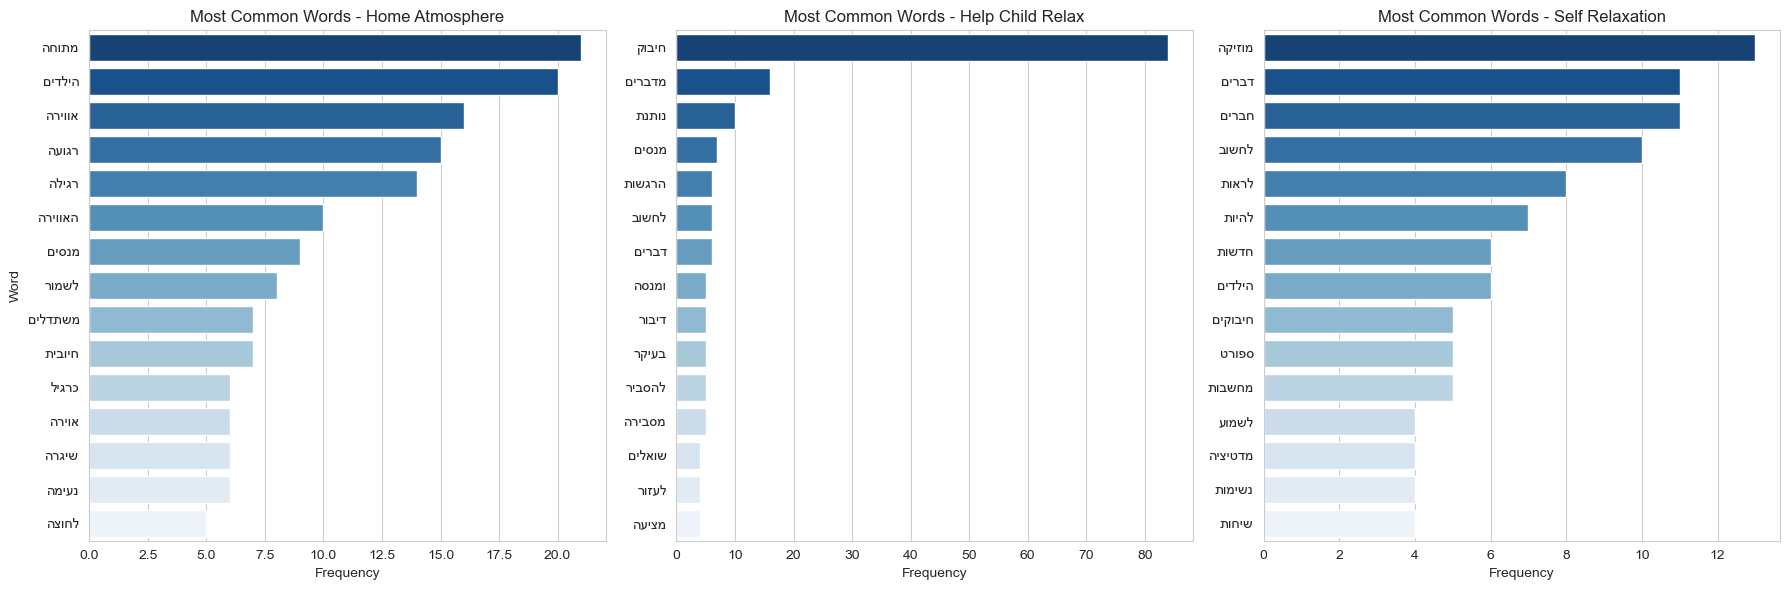

In [78]:
def extract_clean_words(series, normalize_map=None, excluded_words=None):
    if normalize_map is None:
        normalize_map = {}
    if excluded_words is None:
        excluded_words = []
    all_words = []
    for sentence in series.dropna().astype(str):
        for word in sentence.split():
            word = normalize_map.get(word, word)
            if len(word) > 4 and word not in excluded_words:
                all_words.append(word)

    return all_words

normalize_map = {
    "חיבוק": "חיבוק",
    "חיבוק,": "חיבוק",
    "מחבקת": "חיבוק",
    "לחבק": "חיבוק",
    "מחבקים": "חיבוק",
    "חברים,": "חברים",
    "מדיטציה,": "מדטיציה",
}

columns = [
    ("home_atmosphere", "Home Atmosphere"),
    ("help_child_relax", "Help Child Relax"),
    ("self_relax_strategies", "Self Relaxation")
]

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

#גרף ראשון
words1 = extract_clean_words(df["home_atmosphere"], normalize_map)
word_freq1 = Counter(words1).most_common(15)
word_df1 = pd.DataFrame(word_freq1, columns=["Word", "Frequency"])
word_df1["Word"] = word_df1["Word"].apply(reshape_text)

sns.barplot(y=word_df1["Word"], x=word_df1["Frequency"], hue=word_df1["Word"],palette="Blues_r", ax=axes[0], legend=False)
axes[0].set_title("Most Common Words - Home Atmosphere", fontsize=12)
axes[0].set_xlabel("Frequency")
axes[0].set_ylabel("Word")

#גרף 2
words2 = extract_clean_words(df["help_child_relax"], normalize_map)
word_freq2 = Counter(words2).most_common(15)
word_df2 = pd.DataFrame(word_freq2, columns=["Word", "Frequency"])
word_df2["Word"] = word_df2["Word"].apply(reshape_text)

sns.barplot(y=word_df2["Word"], x=word_df2["Frequency"], hue=word_df2["Word"],palette="Blues_r", ax=axes[1], legend=False)
axes[1].set_title("Most Common Words - Help Child Relax", fontsize=12)
axes[1].set_xlabel("Frequency")
axes[1].set_ylabel("")

#גרף שלישי
words3 = extract_clean_words(df["self_relax_strategies"], normalize_map)
word_freq3 = Counter(words3).most_common(15)
word_df3 = pd.DataFrame(word_freq3, columns=["Word", "Frequency"])
word_df3["Word"] = word_df3["Word"].apply(reshape_text)

sns.barplot(y=word_df3["Word"], x=word_df3["Frequency"], hue=word_df3["Word"],palette="Blues_r", ax=axes[2], legend=False)
axes[2].set_title("Most Common Words - Self Relaxation", fontsize=12)
axes[2].set_xlabel("Frequency")
axes[2].set_ylabel("")
plt.tight_layout()
plt.show()



### 👥📊Participant Profile and Demographic Overview
<div dir='rtl'>
חלק זה נעשה על מנת לנסות להכיר את האוכלוסייה עליהם בוצע המחקר בצורה מעמיקה יותר וכך גם לדעת לאיזה סוג שאלות עלינו לכוון במהלך העבודה.
</div>

<div dir='rtl'>
  <strong style="font-size: 18px;">סטטיסטיקות עבור נתוני רקע:</strong>
</div>
<div dir='rtl'>
    הטבלה הבאה מציגה מדדים סטטיסטיים תיאורטיים עבור מספר משתני רקע מרכזיים:
  <br>
    גיל הילד, גיל ההורים, אחוזי משרה בזמן השגרה והמלחמה, ושינויים בשעות התעסוקה בעקבות פרוץ הלחימה.
  <br>
    מטרת הצגה זו היא לספק תמונה כללית על מאפייני אוכלוסיית המדגם.
</div>


In [81]:
dic_df=df[["age_child","parent_age","second_parent_age","parent_job_pct_current_num","second_parent_job_pct_war_num","job_change_parent","job_change_second_parent"]] #ראינו כי ישנו ילד בנתונים אשר הוריו טעו וכתבו שם ככה"נ את תאריך לידתם ועל כן סיננו עד גיל מסויים
filterd_dic=dic_df[dic_df["age_child"]<18]
filterd_dic.describe().style.background_gradient()

,age_child,parent_age,second_parent_age,parent_job_pct_current_num,second_parent_job_pct_war_num,job_change_parent,job_change_second_parent
count,165.000000,165.000000,160.000000,165.000000,157.000000,165.000000,157.000000
mean,6.824242,37.900000,39.250000,77.503030,79.458599,-12.800000,-22.292994
std,2.059930,5.951839,6.194946,41.897468,42.033944,32.606336,45.076468
min,1.000000,24.000000,26.000000,0.000000,0.000000,-150.000000,-150.000000
25%,6.000000,33.000000,35.000000,50.000000,50.000000,-25.000000,-50.000000
50%,7.000000,38.000000,39.500000,100.000000,100.000000,0.000000,0.000000
75%,8.000000,43.000000,44.000000,100.000000,100.000000,0.000000,0.000000
max,15.000000,50.000000,53.000000,150.000000,150.000000,75.000000,100.000000


<div dir='rtl'>
  <strong style="font-size: 18px;">פילוח קבוצות גילאים ע"פ מגדר:</strong>
</div>
<div dir='rtl'>
     הגרפים הבאים מציגים את פילוח קבוצות הגילאים של אוכלוסיית המדגם, תוך חלוקה לפי מגדר ההורה או הילד.
</div>


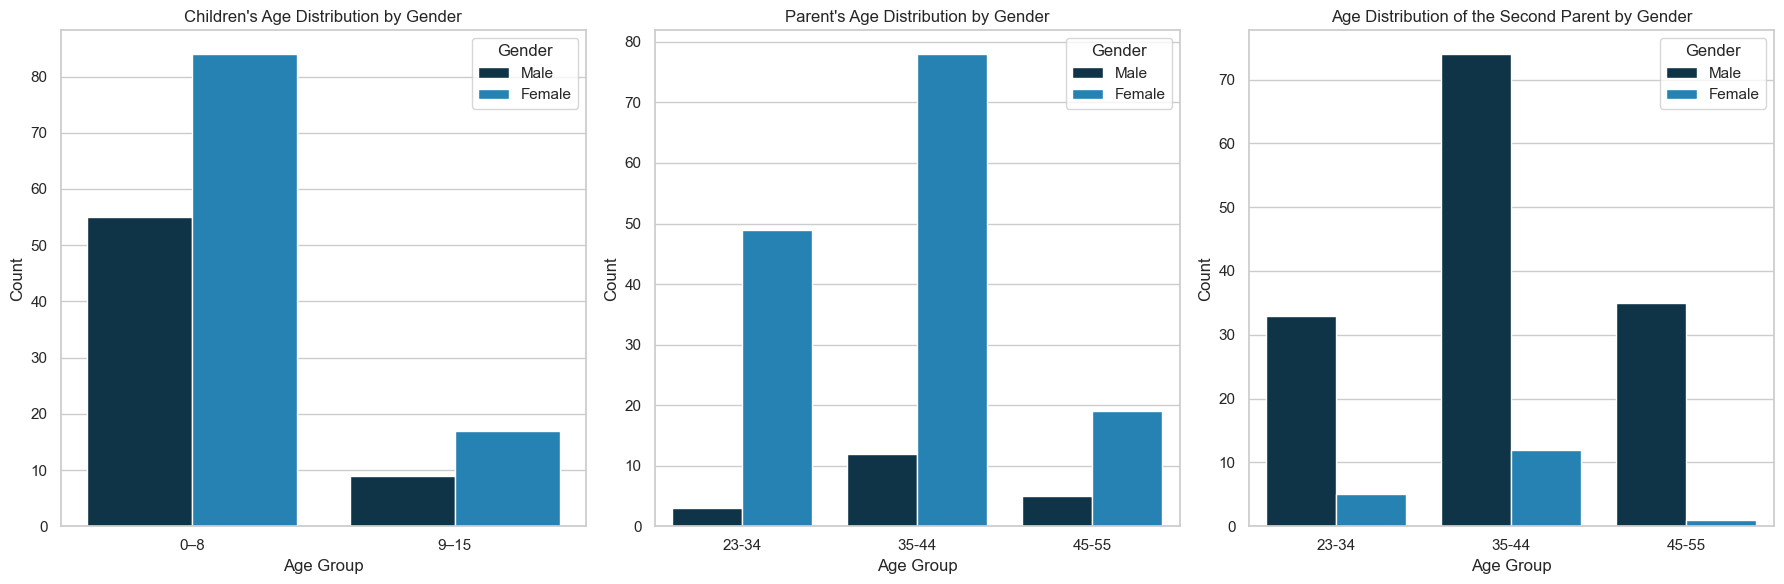

In [83]:
sns.set(style="whitegrid")
colors = ["#063751", "#0E89CB"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.countplot(data=df, x="age_group_child", hue="Gender",hue_order=["Male", "Female"], palette=colors, ax=axes[0])
axes[0].set_title("Children's Age Distribution by Gender")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Count")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["0–8", "9–15"])
axes[0].legend(title="Gender")

sns.countplot(data=df, x="parent_age_group", hue="Gender_parent_TXT", hue_order=["Male", "Female"], palette=colors, ax=axes[1])
axes[1].set_title("Parent's Age Distribution by Gender")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Count")
axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels(["23-34", "35-44", "45-55"])
axes[1].legend(title="Gender")


sns.countplot(data=df, x="second_parent_age_group", hue="second_parent_gender_TXT",hue_order=["Male", "Female"], palette=colors, ax=axes[2])
axes[2].set_title("Age Distribution of the Second Parent by Gender")
axes[2].set_xlabel("Age Group")
axes[2].set_ylabel("Count")
axes[2].set_xticks([0, 1, 2])
axes[2].set_xticklabels(["23-34", "35-44", "45-55"])
axes[2].legend(title="Gender")


plt.tight_layout()
plt.show()

<div dir='rtl'>
ניתן לראות כי רובו המוחלט של ממלאי השאלון הינן אמהות.
</div>

<div dir='rtl'>
  <strong style="font-size: 18px;">התפלגות לפי מצב מגורים נוכחי של המשפחה:</strong>
</div>
<div dir='rtl'>
    התרשים מציג את פילוג המשתתפים בהתאם למצב המגורים הנוכחי שלהם על מנת להציג את נתח אוכלוסיית המדגם שפונו מבתיהם.   
  </p>
</div>


In [86]:
res_counts = df["Family’s Current Residence"].value_counts() 
fig = go.Figure(data=[go.Pie(labels= res_counts.index, marker_colors=['063751', '0E89CB'], values=res_counts.values, textfont_size=15)])
fig.update_layout(width=700, height=500, title='Distribution by Family’s Current Residence Status:', title_x=0.42)
fig.show()

<div dir='rtl'>
ע"פ המוצג בגרף, ניתן לראות כי רובן המוחלט של המשפחות אשר ענו על הסקר לא פונו מבתיהם.
</div>

<div dir='rtl'>
  <strong style="font-size: 18px;">סטטוס גיוס במשפחה:</strong>
</div>
<div dir='rtl'>
    התרשים מדגים את התפלגות המשתתפים בהתאם לשאלה האם אחד מבני המשפחה גויס לשירות מילואים או צבאי בעקבות המלחמה.
</div>


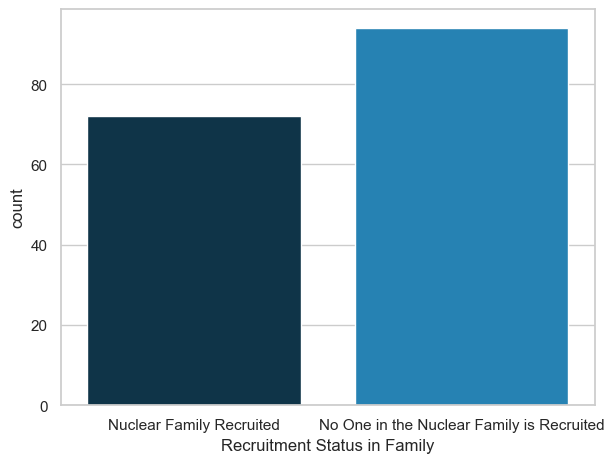

In [89]:
sns.set(style="whitegrid")
colors = ["#063751", "#0E89CB"]
sns.countplot(data=df, x='Recruitment Status in Family',hue='Recruitment Status in Family',palette=colors, legend=False)
plt.xlabel('Recruitment Status in Family')
plt.ylabel('count')
plt.tight_layout()
plt.show()


<div dir='rtl'>
  <strong style="font-size: 18px;">נפגעים במעגל הקרוב:</strong>
</div>
<div dir='rtl'>
    בתרשים זה נבחנת השאלה האם למשתתפים היו קרובים שנפגעו במהלך המלחמה (הרוגים/פצועים/חטופים).
<br>
    משתנה זה חיוני להבנת גודל החשיפה האישית לאירועי טראומה, והשפעתה על תגובות רגשיות והתנהגותיות.
  </p>
</div>


In [91]:
label_map = {1: "No casualties in close circle", 2: "Casualties in close circle"}
df["casualties_label"] = df["casualties_close"].map(label_map)
num_counts = df["casualties_label"].value_counts() 
fig = go.Figure(data=[go.Pie(labels= num_counts.index, marker_colors=['063751', '0E89CB'], values=num_counts.values, textfont_size=15)])
fig.update_layout(width=700, height=500, title='Casualties in Close Circle:', title_x=0.42)
fig.show()

<h2 style="color: #345682">🔍 Correlation Analysis</h2>

#### 🧮 Preparing Data for Correlation

In [94]:
df["the_place_in_fam_encoded"]=pd.Categorical(df["the_place_in_fam"]).codes
df["age_group_child_encoded"]=pd.Categorical(df["age_group_child"]).codes
df["parent_age_group_encoded"]=pd.Categorical(df["parent_age_group"] ).codes
df["second_parent_age_group_encoded"]=pd.Categorical(df["second_parent_age_group"]).codes

In [95]:
df["Gender_child_encoded"] = df["Gender"].map({"Male": 1, "Female": 2})
df['Family’s Current Residence_encoded'] = df["Family’s Current Residence"].map({"Permanent Residence": 0,"Temporary Housing": 1})

In [96]:
religiosity_order = [
    'חילוני',
    'חילוני, מסורתי',
    'מסורתי',
    'מסורתי, דתי',
    'דתי',
    'דתי, חרדי',
    'חרדי'
]
df["religiosity_encoded"] = pd.Categorical(df["religiosity"], categories=religiosity_order, ordered=True).codes

In [97]:
education_levels2 = {
    "בית ספר תיכון": 1,
    "תעודה על תיכונית": 2,
    "השכלה מקצועית": 2,
    "הכשרה מקצועית": 2,
    "תואר ראשון": 3,
    "תואר שני": 4,
    "תואר שלישי": 5,
    "תעודה על תיכונית, הכשרה מקצועית, תואר ראשון": 3,
    "תעודה על תיכונית, הכשרה מקצועית": 2,
    "הכשרה מקצועית, תואר ראשון": 3,
    "תואר ראשון, תואר שני": 4,
    "בית ספר תיכון, תעודה על תיכונית, הכשרה מקצועית": 2
}
df["parent_education_encoded"] = df["parent_education"].replace(education_levels2).astype("Int64")

C:\Users\PC\AppData\Local\Temp\ipykernel_22036\2120198843.py:15: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [98]:
education_levels1 = {
    "בית ספר תיכון": 1,
    "תעודה על תיכונית": 2,
    "השכלה מקצועית": 2,
    "הכשרה מקצועית": 2,
    "תואר ראשון": 3,
    "תואר שני": 4,
    "תואר שלישי": 5,
    "תעודה על תיכונית, תואר ראשון": 3,
    "בית ספר תיכון, הכשרה מקצועית": 2,
    "תעודה על תיכונית, הכשרה מקצועית": 2,
    "תואר שני, תואר שלישי": 5,
    "הכשרה מקצועית, תואר ראשון": 3,
    "תואר ראשון, תואר שני": 4,
    "בית ספר תיכון, תעודה על תיכונית, הכשרה מקצועית": 2
}
df["second_parent_education_encoded"] = df["second_parent_education"].replace(education_levels1).astype("Int64")

C:\Users\PC\AppData\Local\Temp\ipykernel_22036\1203036477.py:17: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



#### 🔗 Correlation:

<div dir='rtl'>
בשלב זה של העבודה, בוצע ניתוח קורלציה בין כלל המשתנים הכמותיים שנאספו או גובשו במהלך תהליך העיבוד, לרבות ממוצעים קבוצתיים שגובשו עבור רגשות ההורים והילדים,.
<br>
המטרה הייתה לחפש קשרים מובהקים בין משתנים, על מנת לחפש כיווני ניתוח מעמיקים יותר בהמשך.
</div>

In [101]:
child_related = ['num_children','Gender_child_encoded','age_group_child_encoded','child_empathy','child emotion regulation-positive','child emotion regulation-negative','easy_regulate_positive','easy_regulate_negative','easy_sleep','nightmares','alarm_fear_child',"the_place_in_fam_encoded",'inc_neg_emotions',"num_rooms"]
parent_family_related = ['parent_age_group_encoded','second_parent_age_group_encoded','parent_aliyah_year','second_parent_aliyah_year','Gender_parent_encoded','second_parent_gender_encoded','parent_job_pct_current_num','second_parent_job_pct_war_num','job_change_parent','job_change_second_parent','parent emotion regulation-reappraisel','parent emotion regulation-suppression','parents emotional expersivness-positive','parents emotional expersivness-negative','casualties_close','news_exposure_binary','Recruitment_Status_binary','Family’s Current Residence_encoded','religiosity_encoded','parent_education_encoded','second_parent_education_encoded']
cor_df=df[child_related+parent_family_related]

In [102]:
correlation_matrix = cor_df.corr(numeric_only = True).round(2)
correlation_matrix

,num_children,Gender_child_encoded,age_group_child_encoded,child_empathy,child emotion regulation-positive,child emotion regulation-negative,easy_regulate_positive,easy_regulate_negative,easy_sleep,nightmares,...,parent emotion regulation-suppression,parents emotional expersivness-positive,parents emotional expersivness-negative,casualties_close,news_exposure_binary,Recruitment_Status_binary,Family’s Current Residence_encoded,religiosity_encoded,parent_education_encoded,second_parent_education_encoded
num_children,1.00,0.09,0.11,-0.01,-0.08,-0.06,0.15,0.10,0.06,0.03,...,-0.10,0.01,0.15,0.14,0.11,0.06,-0.14,0.35,0.06,0.09
Gender_child_encoded,0.09,1.00,0.02,0.13,0.16,-0.07,0.12,0.19,0.05,-0.03,...,0.03,-0.09,-0.12,0.07,0.04,0.02,-0.02,0.06,-0.12,0.06
age_group_child_encoded,0.11,0.02,1.00,0.00,-0.18,-0.02,-0.08,-0.03,0.01,0.07,...,0.03,-0.04,0.15,-0.02,-0.14,0.07,-0.00,-0.03,0.05,0.10
child_empathy,-0.01,0.13,0.00,1.00,0.13,-0.18,0.13,0.20,-0.05,0.20,...,-0.08,0.47,0.07,0.04,0.07,0.01,-0.17,-0.04,0.04,0.02
child emotion regulation-positive,-0.08,0.16,-0.18,0.13,1.00,0.17,-0.00,-0.04,0.04,-0.02,...,0.02,-0.07,-0.20,0.06,-0.13,0.06,0.04,0.24,-0.23,-0.12
child emotion regulation-negative,-0.06,-0.07,-0.02,-0.18,0.17,1.00,-0.22,-0.32,-0.29,0.11,...,-0.09,-0.30,0.16,-0.11,0.00,-0.07,0.21,0.09,-0.13,-0.03
easy_regulate_positive,0.15,0.12,-0.08,0.13,-0.00,-0.22,1.00,0.34,0.28,0.03,...,-0.03,0.24,0.01,0.01,0.02,0.05,-0.01,0.04,0.08,0.00
easy_regulate_negative,0.10,0.19,-0.03,0.20,-0.04,-0.32,0.34,1.00,0.47,-0.11,...,-0.08,0.30,-0.17,0.05,0.02,-0.03,-0.05,0.03,0.08,0.07
easy_sleep,0.06,0.05,0.01,-0.05,0.04,-0.29,0.28,0.47,1.00,-0.28,...,-0.02,0.09,-0.18,-0.04,-0.11,0.02,-0.06,-0.01,0.05,0.07
nightmares,0.03,-0.03,0.07,0.20,-0.02,0.11,0.03,-0.11,-0.28,1.00,...,0.05,-0.03,0.10,0.02,0.05,-0.16,0.12,0.06,-0.03,-0.07


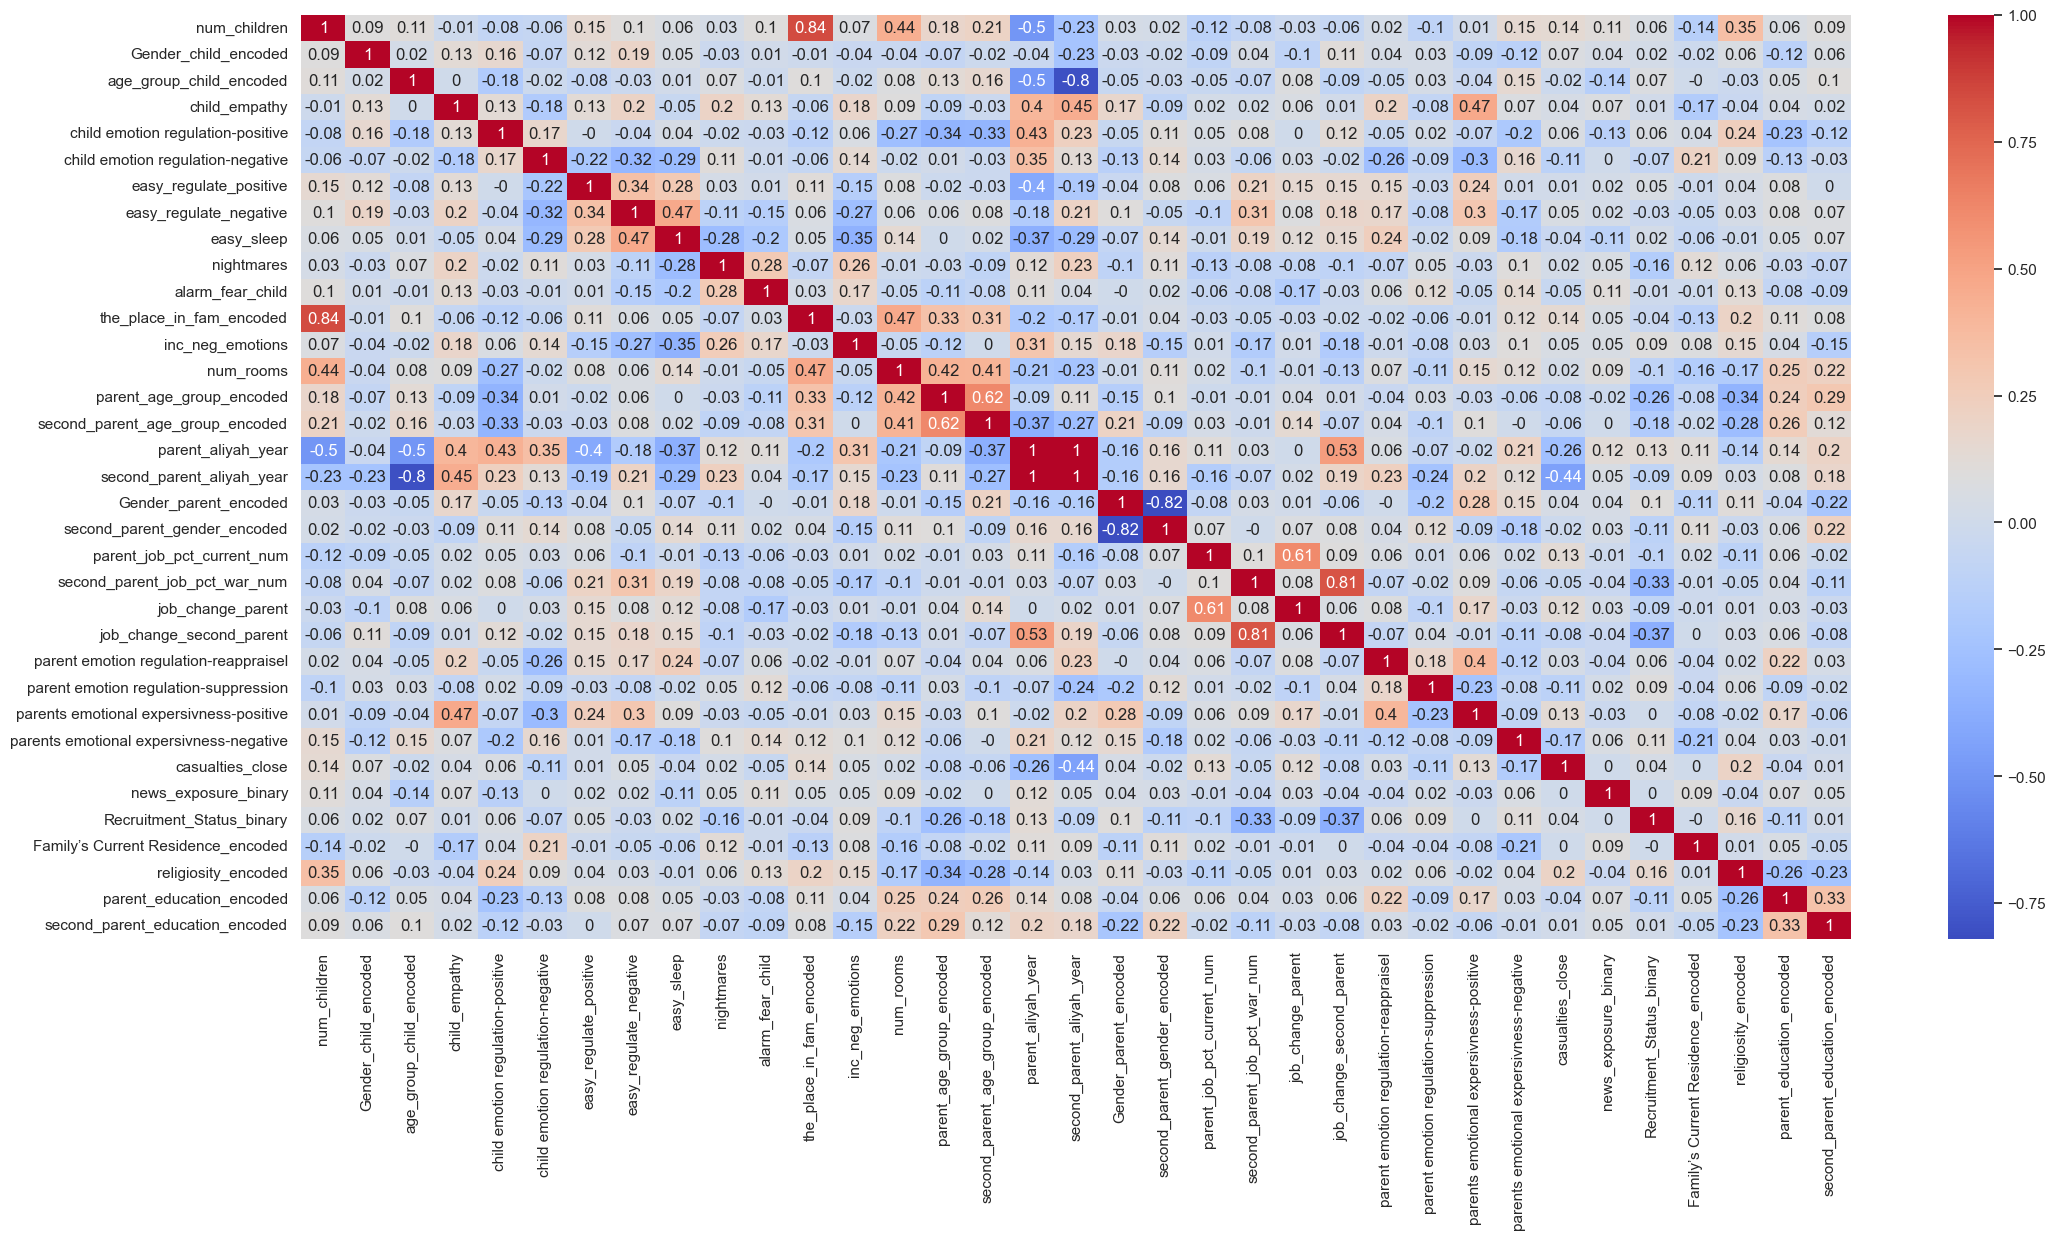

In [103]:
plt.figure(figsize=(25,12))
sns.heatmap(data=correlation_matrix,cmap='coolwarm', annot=True)
plt.show()

<h2 style="color: #345682">📈📘 Emotional Impact of Parental Soothing on Children</h2>

<div dir='rtl'>
  מטרת חלק זה היא לבחון כיצד אסטרטגיות הרגעה שונות בהן נעזרו הורים במהלך תקופת המלחמה משפיעות על היבטים רגשיים והתנהגותיים של ילדיהם.
  <br>
  ניתוח זה מתמקד בשלושה נקודות עיקריות:
  <ul>
    <li>זיהוי שיטות ההרגעה הנפוצות ביותר שנקטו הורים להרגעת ילדיהם.</li>
    <li>
      בחינת ההשפעה של שיטות שונות על המצב הרגשי של הילדים:
      <ul style="list-style-type: circle; padding-right: 20px;">
        <li>כולל התמקדות בשיטות "עצמאי/עקיף" כגון זמן לבד, והסחת דעת.</li>
      </ul>
    </li>
    <li>השוואת יעילות שיטות ההרגעה על מהירות ההירדמות של ילדים, תוך הבחנה בין ילדים שחוו רגרסיה לבין אלו שלא.</li>
  </ul>
</div>


<div dir='rtl'>
  <strong style="font-size: 18px;">ניתוח מילולי של תגובות ההורים – כיצד ניסו להרגיע את ילדיהם?</strong>
</div>

<div dir='rtl'>
כחלק מהבנת הדרכים בהן הורים ניסו לסייע לילדיהם להירגע במהלך תקופת המלחמה, נותחו תשובות פתוחות שניתנו בשאלה חופשית. ניתוח זה התבצע באמצעות יצירת "ענן מילים" – כלי חזותי המאפשר לזהות אילו ביטויים, מילים או מושגים חזרו על עצמם בתדירות גבוהה.
<br>
לפני יצירת הענן בוצע תהליך של ניקוי ואיחוד מילים (למשל, המילים "לחבק", "חיבוקים" ו"מחבקת" אוחדו ל"חיבוק"), במטרה לשקף טוב יותר את הכוונה המקורית של ההורים ולמנוע פיזור מיותר בין וריאציות לשוניות. גודל המילים בענן מייצג את שכיחות הופעתן בדיווחי ההורים.
</div>


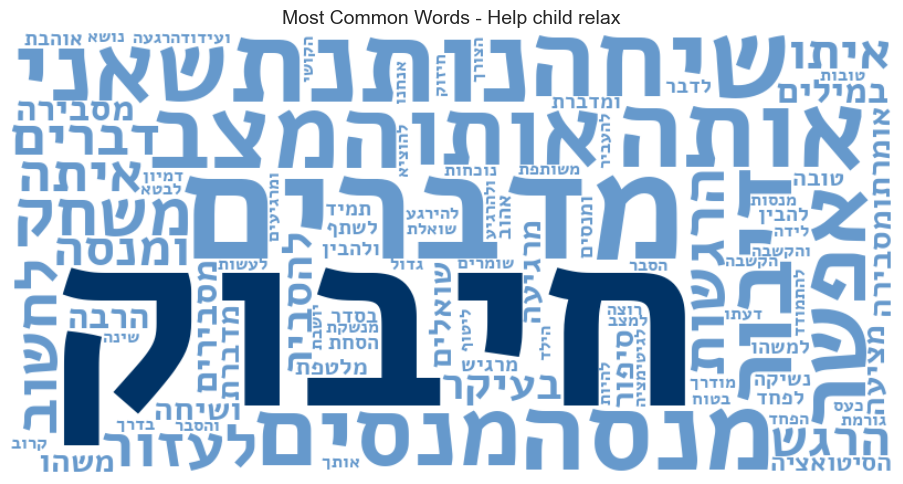

In [107]:
normalize_map = {
    "חיבוקים": "חיבוק",
    "חיבוק,": "חיבוק",
    "מחבקת": "חיבוק",
    "לחבק": "חיבוק",
    "מחבקים": "חיבוק",
    "מתחבקים": "חיבוק",}

all_words = []
for sentence in df["help_child_relax"].dropna().astype(str):
    for word in sentence.split():
        word = word.strip(".,!?\"'")  
        word = normalize_map.get(word, word)  
        if len(word) > 3:
            word = reshape_text(word)
            all_words.append(word)

text = " ".join(all_words)
word_counts = Counter(all_words)
most_common_word = word_counts.most_common(1)[0][0]

def blue_shades_color_func(word, font_size, position, orientation, font_path, random_state):
    if word == most_common_word:
        return "#003366"
    else:
        return "#6699CC"

wordcloud = WordCloud(font_path="Alef-Bold.ttf",width=800,height=400,background_color="white",colormap="Blues",max_words=100,relative_scaling=0.5).generate(text)

plt.figure(figsize=(12, 5))
plt.imshow(wordcloud.recolor(color_func=blue_shades_color_func), interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words - Help child relax", fontsize=14)
plt.tight_layout()
plt.show()


<div dir='rtl'>
ניתן לראות כי המילה הבולטת ביותר שהתגלתה היא <b>חיבוק</b>.
<br>
<div dir='rtl'>
לאחר שזיהינו את המילה הנפוצה ביותר בעמודת השאלה הפתוחה, בחנו את השפעתן על שני מדדים מרכזיים ברווחה הרגשית של הילד לאחר המלחמה: היכולת לווסת רגשות שליליים ורמת האמפתיה שגילה כלפי אחרים.
</div>


<div dir='rtl'>
  <strong style="font-size: 18px;">כיצד שיטות הרגעה שונות משפיעות על המצב הרגשי של ילדים?</strong>
</div>

<div dir='rtl'>
במטרה להבין כיצד שיטות הרגעה שונות שננקטו על ידי ההורים השפיעו על הרווחה הרגשית של ילדיהם לאחר המלחמה, נבחנו שני מדדים מרכזיים: וויסות רגשות שלילי ואמפתיה של הילד.
<br>
הגרף שלפניכם מציג את הממוצעים של שני המדדים עבור כל אחת משיטות ההרגעה, כפי שדווחו על ידי ההורים. מטרת ההשוואה היא לזהות אילו שיטות תרמו ליכולת טובה יותר של הילד לווסת רגשות שליליים ולגלות אמפתיה.
</div>


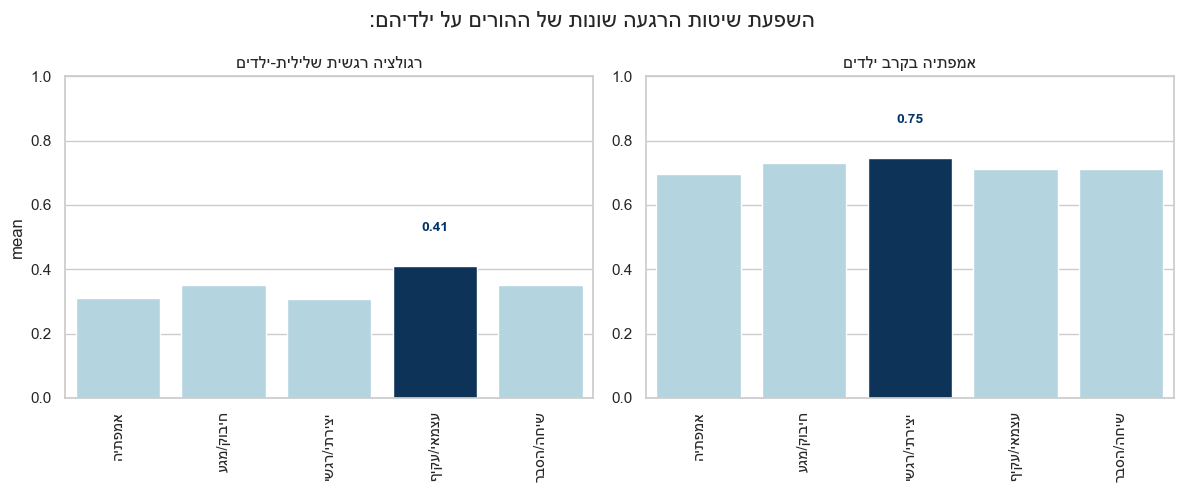

In [110]:
max_semicomma = df.dominant_method.str.count(',').max()
split_df = df["dominant_method"].str.split(",", n=max_semicomma, expand=True)
target = ["child emotion regulation-negative", "child_empathy"]
new_df = pd.concat([df[target], split_df], axis=1)

method_cols = [0, 1, 2, 3]
long_df = new_df.melt(id_vars=target, value_vars=method_cols, value_name="method").copy()
long_df = long_df.dropna(subset=["method"]) 
long_df = long_df[(long_df["method"] != "לא זוהה")]

groupby = long_df.groupby('method')[target].mean().reset_index()

groupby["method_reshaped"] = groupby["method"].apply(reshape_text)

def annotate_max_bar(ax, x_pos, y_val):ax.text(x=x_pos,y=y_val + 0.1,s=f"{y_val:.2f}",ha='center',va='bottom',fontsize=10,fontweight='bold',color='#003366')
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

values_neg = groupby["child emotion regulation-negative"].values
max_idx_neg = np.argmax(values_neg)
palette_neg = ["lightblue"] * len(values_neg)
palette_neg[max_idx_neg] = "#003366"

sns.barplot(data=groupby,x="method_reshaped",y="child emotion regulation-negative",hue="method_reshaped", ax=axes[0],palette=palette_neg,legend=False,errorbar=None)
annotate_max_bar(axes[0], max_idx_neg, values_neg[max_idx_neg])
axes[0].set_title(reshape_text("רגולציה רגשית שלילית-ילדים"), fontsize=12)
axes[0].tick_params(axis="x", rotation=90)
axes[0].set_ylim(0, 1)
axes[0].set_xlabel("")
axes[0].set_ylabel("mean")

values_pos = groupby["child_empathy"].values
max_idx_pos = np.argmax(values_pos)
palette_pos = ["lightblue"] * len(values_pos)
palette_pos[max_idx_pos] = "#003366"

sns.barplot(data=groupby,x="method_reshaped",y="child_empathy",hue="method_reshaped", ax=axes[1],palette=palette_pos,legend=False,errorbar=None)
annotate_max_bar(axes[1], max_idx_pos, values_pos[max_idx_pos])
axes[1].set_title(reshape_text("אמפתיה בקרב ילדים"), fontsize=12)
axes[1].tick_params(axis="x", rotation=90)
axes[1].set_ylim(0, 1)
axes[1].set_xlabel("")
axes[1].set_ylabel("")

plt.suptitle(reshape_text("השפעת שיטות הרגעה שונות של ההורים על ילדיהם:"), fontsize=16)
plt.tight_layout()
plt.show()


<div dir='rtl'>
מהנתונים עולה כי ילדים שהוריהם בחרו בשיטות הרגעה יצירתיות או כאלה שפועלות על הרגש הפגינו על פי דיווחי ההורים אמפטיה גבוהה יותר.
<br>
מנגד, ילדים שהוריהם השתמשו בשיטות הרגעה עצמאיות או עקיפות (זמן לבד או הסחת דעת) מדורגים על ידי הוריהם גם כילדים אשר מביעים וויסות רגשות שליליים באופן גבוה יותר.
</div>

<div dir='rtl'>
לאור הממצאים הקודמים אשר הצביעו על הקשר בין שיטת ההרגעה "עצמאי/עקיף" לבין קשיים בוויסות רגשות שלילים, ביצענו ניתוח נוסף המתמקד בילדים שהוריהם דיווחו על שימוש בשיטה זו.
<br>
מטרת ניתוח זה הייתה לחזק את ההבנה בנוגע להשפעות שונוות של שימוש  בשיטות התמודדות עצמאי/עקיף (זמן לבד או הסחת דעת) במהלך תקופת המלחמה.
</div>


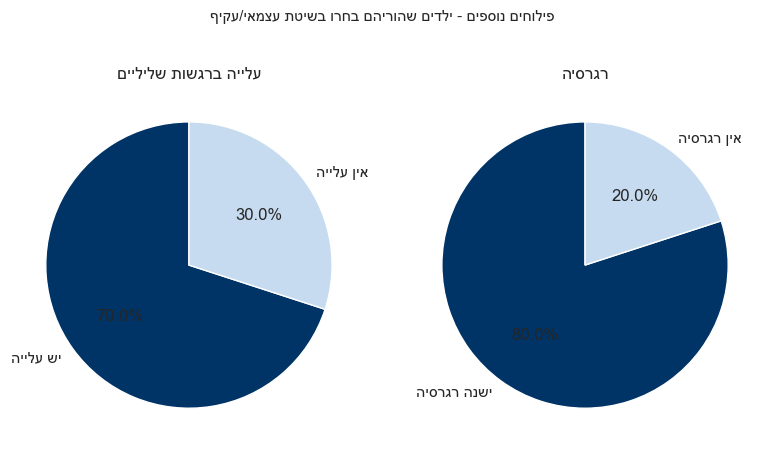

In [113]:
alone_df = df[df["dominant_method"].str.contains("עצמאי/עקיף", na=False)].copy()
inc_neg_counts = alone_df["inc_neg_emotions_binary"].value_counts()
regression_counts = alone_df["regression_cat"].value_counts()

labels_inc = [reshape_text("יש עלייה"), reshape_text("אין עלייה")]
labels_reg = [reshape_text("ישנה רגרסיה"), reshape_text("אין רגרסיה")]

colors = ['#003366', '#c6dbef']
fig, axes = plt.subplots(1, 2, figsize=(8, 5))
axes[0].pie(inc_neg_counts, labels=labels_inc, autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title(reshape_text("עלייה ברגשות שליליים"))

axes[1].pie(regression_counts, labels=labels_reg, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title(reshape_text("רגרסיה"))

plt.suptitle(reshape_text("פילוחים נוספים - ילדים שהוריהם בחרו בשיטת עצמאי/עקיף"), fontsize=11)
plt.tight_layout()
plt.show()


<div dir='rtl'>
ניתן לראות כי מתוך כלל ההורים שבחרו בשיטת "עצמאי/עקיף",  80% היו הורים לילדים עם רגרסיה ו־70% דיווחו על עלייה ברגשות שליליים
</div>

<div dir='rtl'>
<strong style="font-size: 18px;">שיטות הרגעה והשפעתן על מהירות ההירדמות – בקרב ילדים עם וללא רגרסיה</strong>
</div>
<div dir='rtl'>
במטרה להבין כיצד שיטות הרגעה שונות השפיעו על מהירות ההירדמות של ילדים לאחר המלחמה, בדקנו את תשובת ההורים בנוגע למהירות הירדמות ילדיהם, תוך הבחנה בין ילדים שחוו רגרסיה לבין אלו שלא.
</div>

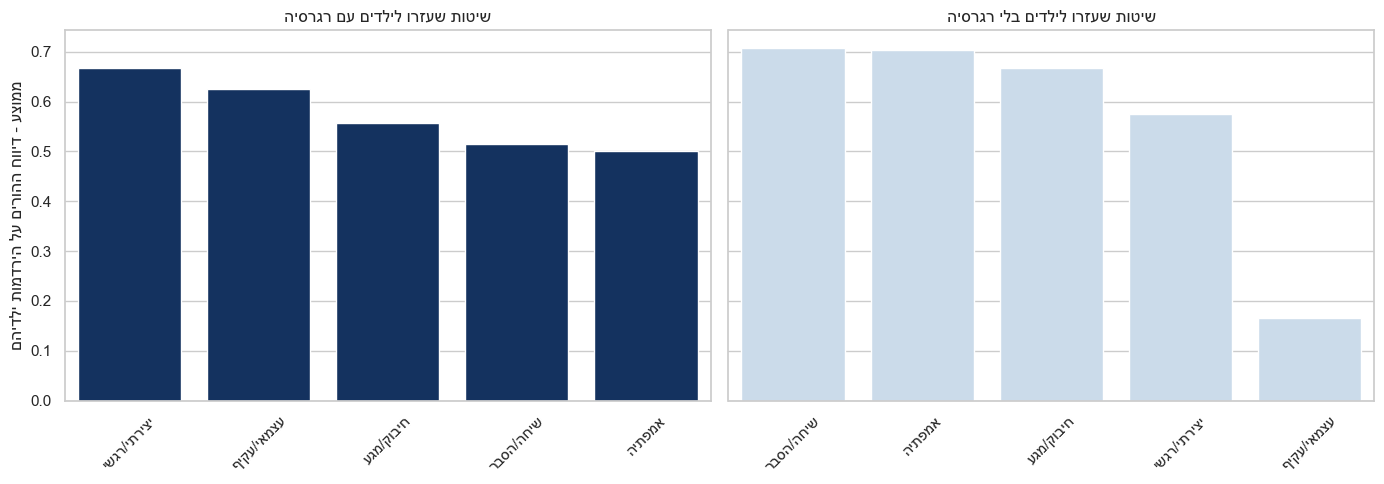

In [116]:
max_semicomma = df.dominant_method.str.count(',').max()
split_df = df["dominant_method"].str.split(",", n=max_semicomma, expand=True)

target = ["easy_sleep", "regression_cat"]
new_df = pd.concat([df[target], split_df], axis=1)

method_cols = split_df.columns.tolist()
long_df = new_df.melt(id_vars=target, value_vars=method_cols, value_name="method")
long_df = long_df.dropna(subset=["method"])
long_df = long_df[~long_df["method"].str.strip().isin(["לא זוהה", "שיר", "סיפור", "משחק"])]

grouped = long_df.groupby(["method", "regression_cat"])["easy_sleep"].mean().reset_index()
grouped["method_reshaped"] = grouped["method"].apply(reshape_text)

with_regression = grouped[grouped["regression_cat"] == "כן"].sort_values("easy_sleep", ascending=False)
without_regression = grouped[grouped["regression_cat"] == "לא"].sort_values("easy_sleep", ascending=False)

with_regression["method_reshaped"] = with_regression["method"].apply(reshape_text)
without_regression["method_reshaped"] = without_regression["method"].apply(reshape_text)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.barplot(data=with_regression, x="method_reshaped", y="easy_sleep", ax=axes[0], color="#08306b")
axes[0].set_title(reshape_text("שיטות שעזרו לילדים עם רגרסיה"))
axes[0].set_xlabel("")
axes[0].set_ylabel(reshape_text("ממוצע - דיווח ההורים על הירדמות ילדיהם"))
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=without_regression, x="method_reshaped", y="easy_sleep", ax=axes[1], color="#c6dbef")
axes[1].set_title(reshape_text("שיטות שעזרו לילדים בלי רגרסיה"))
axes[1].set_xlabel("")
axes[1].set_ylabel("")  
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


<div dir="rtl">
    שילוב שלושת הגרפים מצביע על התמונה הבאה: ע"פ הגרף השני הורים שבחרו בשיטות הרגעה מסוג "עצמאי/עקיף" נטו להיות הורים לילדים שחוו רגרסיה ועלייה ברגשות שליליים.
    <br>
    עם זאת, דווקא בקבוצת ילדים זו (עם רגרסיה), שיטות כמו "יצירתי/רגשי" ו־"עצמאי/עקיף" נקשרו להירדמות קלה יותר.
    <br>
    מנגד, בקרב ילדים שלא חוו רגרסיה, שיטות מבוססות קרבה כמו "חיבוק", "שיחה/הסבר" ו"אמפתיה" נמצאו כיעילות יותר לקידום הירדמות.
    <br>
    ממצאים אלו מדגישים כי אין שיטת הרגעה אחת שמתאימה לכולם – שיטות עקיפות עשויות להועיל במצבי מצוקה, בעוד ששיטות ישירות מתאימות יותר כאשר הילד במצב רגשי יציב.
</div>


<h2 style="color: #345682">📊🧠 Emotional Effects of Parental Self-Calming Strategies</h2>

<div dir='rtl'>
  חלק זה עוסק בבחינת הקשר בין אסטרטגיות הרגעה עצמית שבחרו ההורים לבין מדדים רגשיים, הן ברמה האישית של ההורה והן ברמה הבין-אישית מול הילד:
</div>

<div dir='rtl'>
  <ul>
    <li>זיהוי השיטות הנפוצות ביותר להרגעה עצמית בקרב ההורים.</li>
    <li>בחינת השפעתן של שיטות הרגעה שונות על רמת ההבעה הרגשית החיובית של ההורה, תוך הבחנה לפי קרבה לנפגעים.</li>
    <li>
      השפעת חיבוק כשיטת ויסות רגשי – על הבעת רגשות חיוביים של ההורה ואמפתיה של הילד:
      <ul style="list-style-type: circle; padding-right: 20px;">
        <li>ע"פ חלוקה להורים אשר משתמשים בחיבוק כשיטת הרגעה עצמית והרגעת ילדיהם לעומת הורים שמשתמשים בחיבוק להרגעת ילדיהם בלבד./li>
      </ul>
    </li>
  </ul>
</div>


<div dir='rtl'>
  <strong style="font-size: 18px;">ניתוח מילולי של תגובות ההורים – כיצד ניסו להרגיע את עצמם?</strong>
</div>


<div dir='rtl'>
במטרה להבין כיצד הורים התמודדו בעצמם עם האתגר הרגשי בזמן הלחימה, ניתחנו את התשובות הפתוחות שסיפקו במסגרת השאלון. ענן המילים שלפניכם מציג את הביטויים הבולטים שחזרו על עצמם בתיאורי שיטות ההרגעה העצמית של ההורים.
<br>
לצורך ניתוח אחיד, מונחים דומים אוחדו לקטגוריות משותפות (לדוגמה: "שירים", "שרים", ו"מוזיקה" סווגו תחת "מוזיקה"). ככל שמילה מופיעה בגודל גדול יותר, הייתה שכיחה יותר בתשובות – ובכך היא מצביעה על אסטרטגיות ההרגעה המרכזיות שעמדו לרשות ההורים במהלך התקופה.
</div>


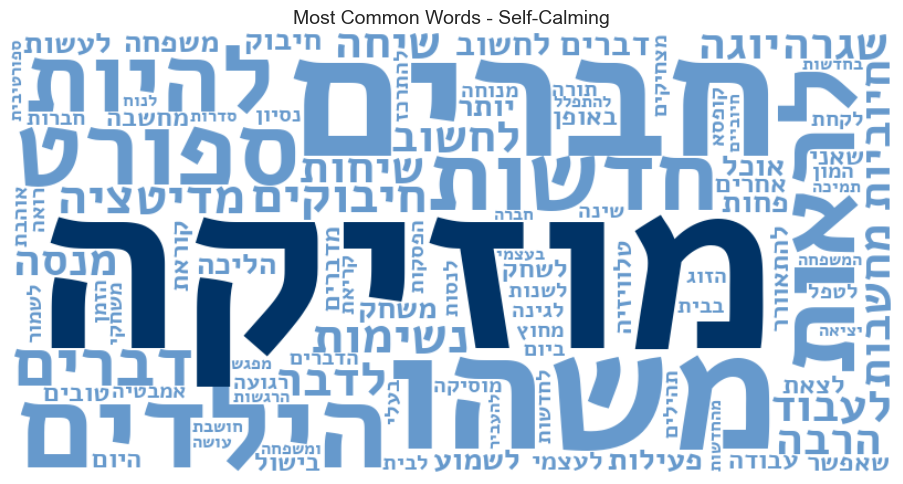

In [121]:
normalize_map = {
    "חיבוק": "חיבוק",
    "חיבוק,": "חיבוק",
    "מחבקת": "חיבוק",
    "לחבק": "חיבוק",
    "מחבקים": "חיבוק",
    "שיר": "מוזיקה",
    "שירים": "מוזיקה",
    "שרים": "מוזיקה",
    "לשיר": "מוזיקה",
    "מוזיקה": "מוזיקה",
    "מנגנים": "מוזיקה",
    "שומעים מוזיקה": "מוזיקה"
}

all_words = []

for sentence in df["self_relax_strategies"].dropna().astype(str):
    for word in sentence.split():
        word = word.strip(".,!?\"'") 
        word = normalize_map.get(word, word) 
        if len(word) > 3:
            word = reshape_text(word)  
            all_words.append(word)

text = " ".join(all_words)
word_counts = Counter(all_words)
most_common_word = word_counts.most_common(1)[0][0]
def blue_color(word, font_size, position, orientation, font_path, random_state): #חייבת את כל ה-4 ארגומנטים 
    if word == most_common_word:
        return "#003366"
    else:
        return "#6699CC"

wordcloud = WordCloud(font_path="Alef-Bold.ttf",width=800,height=400,background_color="white",colormap="Blues",max_words=100,relative_scaling=0.5).generate(text)

plt.figure(figsize=(12, 5))
plt.imshow(wordcloud.recolor(color_func=blue_color), interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words - Self-Calming", fontsize=14)
plt.tight_layout()
plt.show()

<div dir='rtl'>
ניתן לראות כי המילה הכי נפוצה הינה <b>מוזיקה</b>.
<br>
כעת, נרצה לבדוק מהי דרך ההרגעה שהשפיעה בצורה המירבית הן על ההורים ועל הילדים. 
</div>

<div dir='rtl'>
  <strong style="font-size: 18px;">השפעת שיטות הרגעה עצמאיות על הבעה רגשית חיובית של ההורים לפי קרבה לנפגעים</strong>
</div>

<div dir='rtl'>
מכיוון שנמצא כי הבעת רגשות חיוביים מצד ההורה קשורה לרמות האמפתיה של הילד, נבחנו כאן שיטות הרגעה עצמית שדווחו על ידי ההורים, כדי לזהות אילו מהן תורמות יותר לביטוי רגשות חיוביים – ובכך עשויות להשפיע גם בעקיפין על הילד. 
<br>
הגרפים מציגים שלוש קבוצות שיטות:
<ul>
  <li><strong>הורים עם קרובים שנפגעו:</strong> שיטות שהיו יעילות יותר להורים עם קרובים שנפגעו במהלך המלחמה</li>
  <li><strong>הורים ללא קרובים שנפגעו:</strong> שיטות שעזרו יותר ללא קרובים שנפגעו במהלך המלחמה</li>
  <li><strong>השפעה שווה:</strong> שיטות שהשפיעו באותה מידה על שתי הקבוצות.</li>
</ul>
</div>


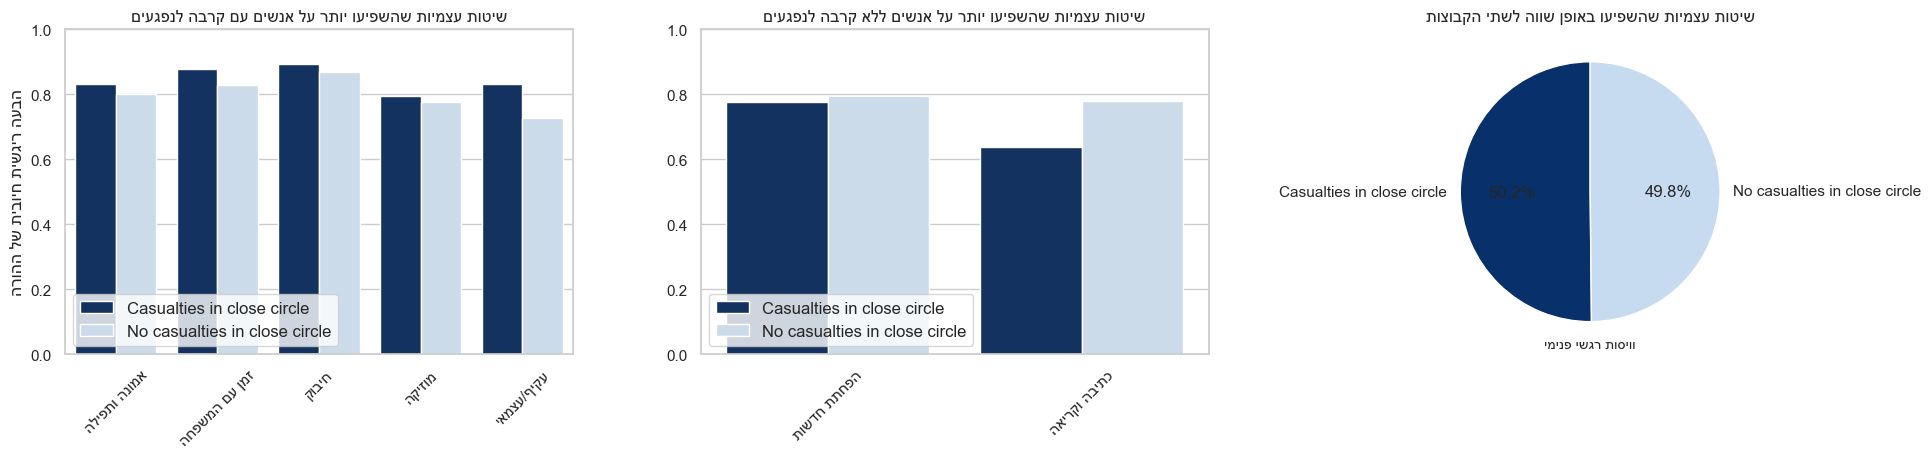

In [124]:
max_comma3 = df["dominant_method_self"].str.count(',').max()
split_df3 = df["dominant_method_self"].str.split(',', n=max_comma3, expand=True)

target = ["parents emotional expersivness-positive", "casualties_label"]
new_df3 = pd.concat([df[target], split_df3], axis=1)
method_cols = split_df3.columns.tolist()

long_df3 = new_df3.melt(id_vars=target, value_vars=method_cols, value_name="method").copy()
long_df3 = long_df3.dropna(subset=["method"])
long_df3 = long_df3[(long_df3["method"].str.strip() != "לא זוהה") &(long_df3["method"].str.strip() != "אוכל") &(long_df3["method"].str.strip() != "וירבלי") &(long_df3["method"].str.strip() != "פעילות גופנית") &(long_df3["method"].str.strip() != "עשייה ועבודה")&(long_df3["method"].str.strip() != "שמירה על שגרה")&(long_df3["method"].str.strip() != "צפייה ובידור")]


grouped3 = long_df3.groupby(["method", "casualties_label"]).agg({"parents emotional expersivness-positive": "mean"}).reset_index()
pivot_df3 = grouped3.pivot(index="method", columns="casualties_label", values="parents emotional expersivness-positive").reset_index()

def categorize(row, epsilon=0.01): 
    val1 = row["Casualties in close circle"]
    val2 = row["No casualties in close circle"]
    if pd.isna(val1) or pd.isna(val2):
        return "לא מסווג"
    elif abs(val1 - val2) < epsilon:
        return "שווה"
    elif val1 > val2:
        return "עוזר עם קרובים"
    else:
        return "עוזר בלי קרובים"

pivot_df3["category"] = pivot_df3.apply(categorize, axis=1)
pivot_df3["method_heb"] = pivot_df3["method"].apply(reshape_text)

palette = {"Casualties in close circle": "#08306b","No casualties in close circle": "#c6dbef"}

# מכינים תתי-תרשימים
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

#גרף של עוזר שיש לו קרובים
df_with = pivot_df3[pivot_df3["category"] == "עוזר עם קרובים"]
df_with_melt = df_with.melt(id_vars=["method_heb"], value_vars=["Casualties in close circle", "No casualties in close circle"],var_name="casualties_label", value_name="parents emotional expersivness-positive")
sns.barplot(data=df_with_melt, x="method_heb", y="parents emotional expersivness-positive", hue="casualties_label", palette=palette, ax=axes[0])
axes[0].set_title(reshape_text("שיטות עצמיות שהשפיעו יותר על אנשים עם קרבה לנפגעים"))
axes[0].set_ylabel(reshape_text("הבעה ריגשית חיובית של ההורה"))
axes[0].set_xlabel("")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(loc='lower left', fontsize=12) 


#גרף של עוזר שאין לו קרובים
df_without = pivot_df3[pivot_df3["category"] == "עוזר בלי קרובים"]
df_without_melt = df_without.melt(id_vars=["method_heb"], value_vars=["Casualties in close circle", "No casualties in close circle"],var_name="casualties_label", value_name="parents emotional expersivness-positive")
sns.barplot(data=df_without_melt, x="method_heb", y="parents emotional expersivness-positive", hue="casualties_label", palette=palette, ax=axes[1])
axes[1].set_title(reshape_text("שיטות עצמיות שהשפיעו יותר על אנשים ללא קרבה לנפגעים"))
axes[1].set_ylabel("")
axes[1].set_xlabel("")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(loc='lower left', fontsize=12) 


#שווה
df_equal = pivot_df3[pivot_df3["category"] == "שווה"]
sum_equal = df_equal[["Casualties in close circle", "No casualties in close circle"]].sum()
method_names = ", ".join(df_equal["method_heb"].tolist())
axes[2].pie(sum_equal, labels=["Casualties in close circle", "No casualties in close circle"], autopct='%1.1f%%', colors=["#08306b", "#c6dbef"], startangle=90)
axes[2].set_title(reshape_text("שיטות עצמיות שהשפיעו באופן שווה לשתי הקבוצות"))
axes[2].set_ylabel("")
axes[2].set_xlabel("")
axes[2].tick_params(axis='x', rotation=45)
axes[2].text(0, -1.2,method_names, ha='center', fontsize=10)


plt.tight_layout(rect=[0, 0, 1, 0.95]) #מסדר את כל המיקום של הגרפים
plt.show()


<div dir="rtl">
מהגרפים עולה כי שיטות הרגעה עצמית מסוימות השפיעו באופן שונה על ההבעה הרגשית החיובית של הורים – בהתאם לקרבתם האישית לנפגעים.
<br>
<div dir="rtl">
<ul>
  <li>
    <strong>בקרב הורים עם קרבה לנפגעים:</strong>  
    שיטות כמו,<strong>זמן עם המשפחה</strong>, <strong>עקיף/עצמאי</strong> ו־<strong>אמונה ותפילה</strong>  
    נקשרו לרמות גבוהות יותר של הבעה רגשית חיובית בקרב הורים עם קרבה אישית לנפגעים.
    <br>
    בנוסף, ניתן לראות כי שיטות כמו <strong>חיבוק</strong>, <strong>מוזיקה</strong> עוזרות גם להורים ללא קרבה לנפגעים ברמה גבוהה.
  </li>

  <li>
    <strong>בקרב הורים ללא קרבה לנפגעים:</strong>  
    שיטות כמו <strong>כתיבה וקריאה</strong> ו־<strong>הפחתת חדשות</strong>  
    נקשרו לרמות גבוהות יותר של הבעה רגשית חיובית דווקא בקרב הורים שלא חוו פגיעה באדם קרוב .
  </li>

  <li>
    <strong>שיטות שהשפיעו באופן שווה:</strong>  
  השיטה היחידה שהשפעתה הייתה כמעט זהה על שתי הקבוצות הייתה <strong>וויסות רגשי פנימי</strong>.  
  ייתכן כי שיטה זו מהווה אמצעי כללי להבעת רגשות, המתאים הן לאנשים שחוו טראומה ישירה והן לאלה שלא,  
  היות והפער בין הקבוצות היה זניח (פחות מ־1%).
  </li>
</ul>

</div>


<div dir='rtl'>
  <strong style="font-size: 18px;">השפעת חיבוק כשיטת הרגעה – על הבעת רגשות חיוביים של ההורה ואמפתיה של הילד</strong>
<div dir='rtl'>
    חיבוק כשיטת הרגעה עבור ילדים הייתה השיטה הנפוצה ביותר, ורוב ההורים דיווחו על שימוש בה כלפי ילדיהם (ולא כלפי עצמם), בנוסף מההמצאים בשאלה הראשונה עולה כי הורים אשר הרגיעו את ילדיהם בעזרת חיבוק הראו אמפתיה גבוהה יותר.
    <br>
    תחילה נתעמק בהשוואה בין הקשר בין ביטוי רגשות חיוביים של ההורה לאמפתיית הילד כאשר שיטת הרגעה הייתה חיבוק.
</p>

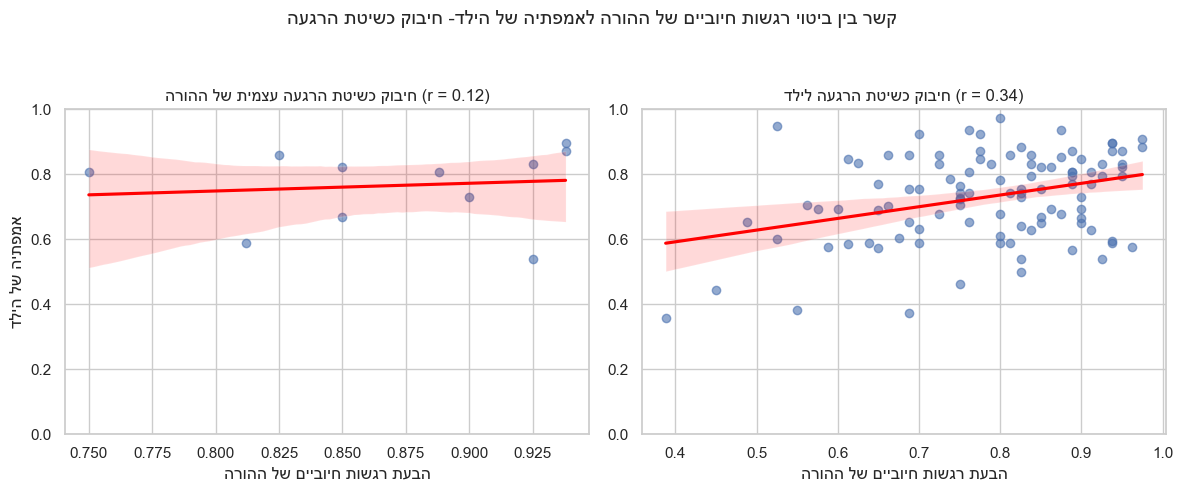

In [127]:
hug_df1 = df[df["dominant_method_self"].str.contains("חיבוק", na=False)]
hug_df2 = df[df["dominant_method"].str.contains("חיבוק/מגע", na=False)]

corr_hug1 = hug_df1["child_empathy"].corr(hug_df1["parents emotional expersivness-positive"])
corr_hug2 = hug_df2["child_empathy"].corr(hug_df2["parents emotional expersivness-positive"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.regplot(data=hug_df1,x="parents emotional expersivness-positive",y="child_empathy",ax=axes[0],scatter_kws={"alpha": 0.6},line_kws={"color": "red"})
axes[0].set_title(f"{reshape_text('חיבוק כשיטת הרגעה עצמית של ההורה')} (r = {corr_hug1:.2f})")
axes[0].set_xlabel(reshape_text("הבעת רגשות חיוביים של ההורה"))
axes[0].set_ylabel(reshape_text("אמפתיה של הילד"))
axes[0].set_ylim(0, 1)


sns.regplot(data=hug_df2,x="parents emotional expersivness-positive",y="child_empathy",ax=axes[1],scatter_kws={"alpha": 0.6},line_kws={"color": "red"})
axes[1].set_title(f"{reshape_text('חיבוק כשיטת הרגעה לילד')} (r = {corr_hug2:.2f})")
axes[1].set_xlabel(reshape_text("הבעת רגשות חיוביים של ההורה"))
axes[1].set_ylabel("")
axes[1].set_ylim(0, 1)


plt.suptitle(reshape_text("קשר בין ביטוי רגשות חיוביים של ההורה לאמפתיה של הילד- חיבוק כשיטת הרגעה"), fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

<div dir='rtl'>
בהשוואה בין שני הגרפים ניתן לראות כי הקשר בין הבעת רגשות חיוביים של ההורה לבין האמפתיה של הילד חזק יותר כאשר ההורה משתמש בשיטת ההרגעה חיבוק כלפי הילד שלו ישירות.
</div>

<div dir='rtl'>
כעת נבדוק את התתפלגות בין ההורים שהשתמשו בחיבוק כשיטת הרגעה עצמית וכשיטת הרגעה לילדיהם.
</p>

In [130]:
df["hug_child"] = df["dominant_method"].fillna("").str.contains("חיבוק/מגע") #אם יש ערכים חסרים זה מחזיר שגיאה ולכן fill
df["hug_self"] = df["dominant_method_self"].fillna("").str.contains("חיבוק") #כנ"ל

summary = df.groupby(["hug_child", "hug_self"]).size().reset_index(name="count") #בודק כמה יש לקבוצה

summary["hug_child"] = summary["hug_child"].map({True: "חיבוק/מגע לילד",False: "ללא חיבוק/מגע לילד"})
summary["hug_self"] = summary["hug_self"].map({True: "חיבוק כשיטת הרגעה עצמית",False: "ללא חיבוק כשיטת הרגעה עצמית"})
labels = list(pd.unique(pd.Series(summary["hug_child"].tolist() + summary["hug_self"].tolist())))

label_to_index = {label: i for i, label in enumerate(labels)}

summary["source_index"] = summary["hug_child"].map(label_to_index)
summary["target_index"] = summary["hug_self"].map(label_to_index)

fig = go.Figure(data=[go.Sankey(node=dict(pad=15,thickness=30,line=dict(color="black", width=0.5),label=labels),link=dict(source=summary["source_index"],target=summary["target_index"],value=summary["count"]))])
fig.update_layout(title=dict(text="התפלגות השימוש בחיבוק להרגעת הילד לבין שימוש בו כשיטת הרגעה עצמית",x=0.5) ,font_size=14,width=1200,height=400)

fig.show()


<div dir='rtl'>
ניתן לראות כי רוב ההורים, בין אם בחרו בחיבוק כאסטרטגיית הרגעה עצמית ובין אם לא, נוטים להשתמש בחיבוק ובמגע כלפי ילדיהם. עם זאת, קיימת חפיפה חלקית בלבד בין הורים שמרגיעים את ילדיהם באמצעות חיבוק לבין הורים שעושים שימוש בחיבוק גם כלפי עצמם.
</div>


<div dir='rtl'>
בשלב זה נבחן האם קיימים הבדלים ברמת האמפתיה של הילד וברמת ההבעה הרגשית החיובית של ההורה, תוך התמקדות בהורים שעשו שימוש בחיבוק כשיטת הרגעה – בין הקבוצות:
    <br>
1. הורים שבחרו בחיבוק המופנה לילד בלבד 
    <br>
2. הורים שבחרו בחיבוק המופנה גם לילד וגם לעצמם
</p>

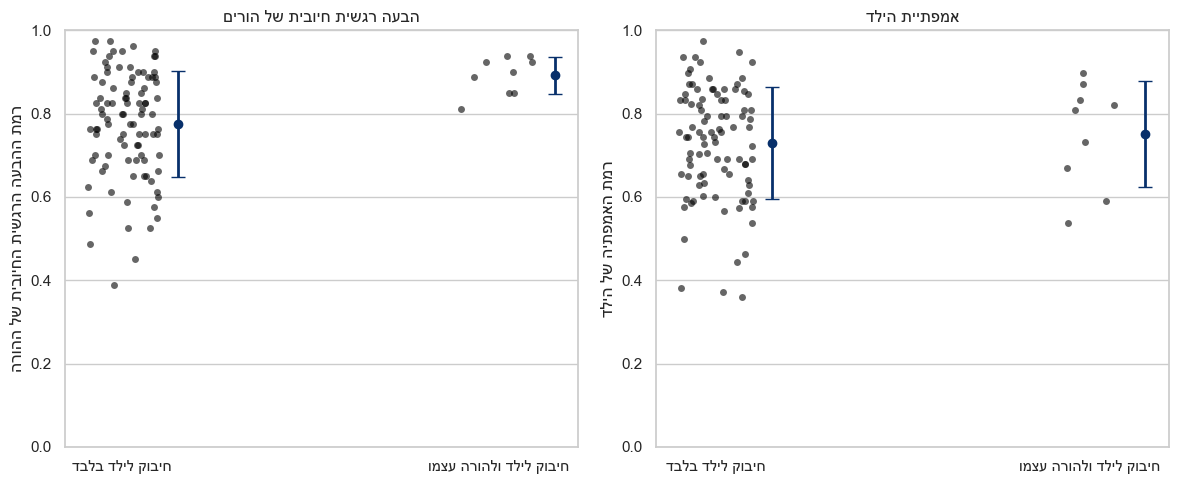

In [133]:
df["hug_combined"] = "nan" 
df.loc[(df["hug_child"] == True) & (df["hug_self"] == False), "hug_combined"] = "חיבוק לילד בלבד"
df.loc[(df["hug_child"] == True) & (df["hug_self"] == True),  "hug_combined"] = "חיבוק לילד ולהורה עצמו"
df["hug_combined_reshaped"] = df["hug_combined"].apply(reshape_text)
df_hugs = df[df["hug_combined"].isin(["חיבוק לילד בלבד", "חיבוק לילד ולהורה עצמו"])].copy()
df_hugs = df_hugs.dropna(subset=["hug_combined_reshaped", "parents emotional expersivness-positive", "child_empathy"])

x_order = df_hugs["hug_combined_reshaped"].unique() 
x_offset = 0.15

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

sns.stripplot(data=df_hugs,x="hug_combined_reshaped",y="parents emotional expersivness-positive",jitter=True,alpha=0.6,ax=axes[0],color='black',order=x_order)

means = df_hugs.groupby("hug_combined_reshaped")["parents emotional expersivness-positive"].mean()
stds = df_hugs.groupby("hug_combined_reshaped")["parents emotional expersivness-positive"].std()

for i, category in enumerate(x_order):
    mean = means[category]
    std = stds[category]
    axes[0].errorbar(x=i + x_offset,y=mean,yerr=std,fmt='o',color='#08306b',capsize=5,elinewidth=2)

axes[0].set_title(reshape_text("הבעה רגשית חיובית של הורים"))
axes[0].set_ylabel(reshape_text("רמת ההבעה הרגשית החיובית של ההורה"))
axes[0].set_xlabel("")
axes[0].set_xticks(range(len(x_order)))
axes[0].set_xticklabels(x_order)
axes[0].set_ylim(0, 1)


sns.stripplot(data=df_hugs,x="hug_combined_reshaped",y="child_empathy",jitter=True,alpha=0.6,ax=axes[1],color='black',order=x_order)

means = df_hugs.groupby("hug_combined_reshaped")["child_empathy"].mean()
stds = df_hugs.groupby("hug_combined_reshaped")["child_empathy"].std()

for i, category in enumerate(x_order):
    mean = means[category]
    std = stds[category]
    axes[1].errorbar(x=i + x_offset,y=mean,yerr=std,fmt='o',color='#08306b',capsize=5,elinewidth=2)

axes[1].set_title(reshape_text("אמפתיית הילד"))
axes[1].set_ylabel(reshape_text("רמת האמפתיה של הילד"))
axes[1].set_xlabel("")
axes[1].set_xticks(range(len(x_order)))
axes[1].set_xticklabels(x_order)
axes[1].set_ylim(0, 1)


plt.tight_layout()
plt.show()


<div dir='rtl'>
  <strong>מסקנות מהגרפים:</strong>
  <ul>
    <li><strong>הבעה רגשית חיובית של ההורים:</strong> 
      <ul><ul style="list-style-type: circle; padding-right: 20px;">
        <li>הורים שחיבקו גם את עצמם וגם את הילד הראו ממוצע גבוה יותר של הבעה רגשית חיובית לעומת אלו שחיבקו רק את הילד.</li>
        <li>סטיית התקן בקבוצת "חיבוק לילד בלבד" הייתה גבוהה יותר – מה שמעיד על פיזור רחב יותר בתגובות הרגשיות של ההורים.</li>
      </ul>
    </li>
    <li><strong>אמפתיית הילד:</strong> 
      <ul> <ul style="list-style-type: circle; padding-right: 20px;">
        <li>ממוצע האמפתיה בקרב ילדים שההורה חיבק רק אותם לבין ילדים אשר הוריהם השתמשו בחיבוק גם עבור ילדיהם וגם עבור עצמם כמעט זהה.</li>
      </ul>
    </li>
  </ul>
</div>
      <ul style="list-style-type: circle; padding-right: 20px;">



<div dir='rtl'>
  <strong>מסקנה כללית:</strong>
  <ul>
    <li>תחילה נמצא כי קיים הבדל משמעותי בעוצמת הקשר בין אמפתיית הילד לבין הבעת רגשות חיוביים של ההורה, בהתאם לשימוש בחיבוק כשיטת הרגעה – כאשר הקשר היה חזק יותר כאשר החיבוק הופנה כלפי הילד.</li>
    <li>בהמשך נמצא כי קיימת חפיפה חלקית בלבד בין הורים שמרגיעים את ילדיהם באמצעות חיבוק לבין הורים שעושים בו שימוש גם להרגעה עצמית. למרות שמדובר במדגם קטן (כ־10%), ניתן לראות כי ילדים של הורים שהשתמשו בחיבוק לשני הכיוונים הראו רמות אמפתיה דומות, אך ההורים עצמם הפגינו הבעת רגשות חיוביים גבוהה יותר.</li>
  </ul>
</div>


<h2 style="color: #345682">🗞️ Emotional Impact of Parental News Consumption</h2>

<div dir='rtl'>
בחלק זה בחרנו להתמקד בשאלה – כיצד החשיפה לחדשות משפיעה על מדדים רגשיים בקרב הורים וילדים:
<br>
הניתוח כולל שלושה מוקדים עיקריים:
</div>

<div dir='rtl'>
<ul>
   <li>התפלגות רמת החשיפה לחדשות לבין האווירה הרגשית בבית כפי שהיא נתפסת על ידי ההורים.</li>
   <li>התפלגות וממוצע וויסות רגשות שליילים בקרב הורים ע"פ חלוקה לרמת חשיפה</li>
  <li>השפעת רמת החשיפה לחדשות על רגשות חיוביים ואמפתיה בקרב ילדים, תוך הבחנה בין קבוצות גיל.</li>
</ul>
</div>

<div dir='rtl'>
  <strong style="font-size: 18px;">התפלגות רמת החשיפה לחדשות על האווירה בבית</strong>
</div>

<div dir='rtl'>
במטרה לבחון האם רמות החשיפה של ההורים לחדשות משפיעה על האווירה הכללית בבית בתקופת המלחמה, נבנה תרשים Sankey המציג את ההתפלגות בין רמות החשיפה לחדשות לבין קטגוריות של האווירה הכללית שדווחה בבית. 
<br>
התרשים מראה האם הורים שהעידו כי צרכו הרבה בחדשות במהלך המלחמה גם העידו שהאווירה בביתהם מתוחה.
</div>

In [139]:
df_sankey = df[['news_freq_level', 'home_atmosphere_cat']].dropna()
labels = pd.unique(pd.concat([df_sankey['news_freq_level'], df_sankey['home_atmosphere_cat']])).tolist()
label_map = {label: i for i, label in enumerate(labels)}
link_df = df_sankey.groupby(['news_freq_level', 'home_atmosphere_cat']).size().reset_index(name='count')
source = link_df['news_freq_level'].map(label_map)
target = link_df['home_atmosphere_cat'].map(label_map)
value = link_df['count']
fig = go.Figure(data=[go.Sankey(node=dict(pad=15,thickness=20,line=dict(color="black", width=0.5),label=labels),link=dict(source=source,target=target,value=value))])

fig.update_layout(title_text='רמת חשיפה לחדשות מול אווירה מתוחה בבית', title_x=0.45 ,font_size=14,width=1200,height=400)
fig.show()


<div dir='rtl'>
תרשים ה־Sankey מציג כי מבין ההורים אשר העידו כי האווירה בביתהם מתוחה, חשיפתם לחדשות הייתה גבוהה יותר אך גם רוב האנשים שהעידו כי האווירה בביתהם רגועה העידו כי חשיפתם לחדשות הייתה גבוהה.  
</div>

<div dir='rtl'>
  <strong style="font-size: 18px;">התפלגות וממוצע וויסות רגשות שליילים בקרב הורים ע"פ חלוקה לרמת חשיפה</strong>
</div>

C:\Users\PC\AppData\Local\Temp\ipykernel_22036\3024671101.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




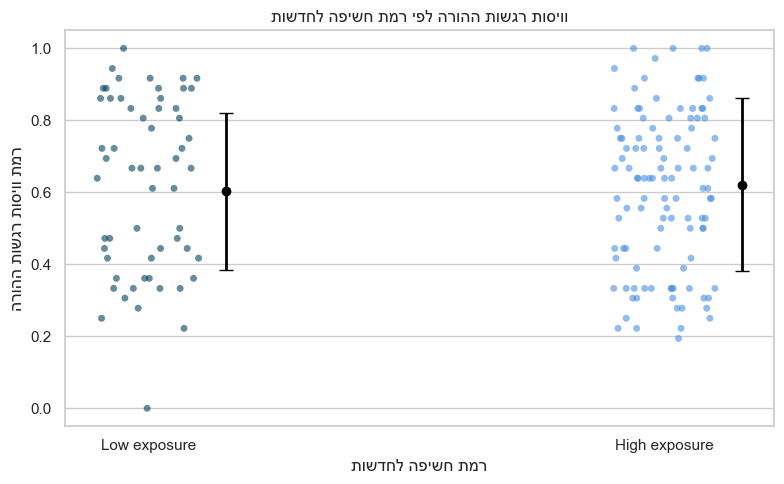

In [142]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_data = df[df['news_freq_level'].isin(['High exposure', 'Low exposure'])].copy()
label_map = {'High exposure': 'High exposure', 'Low exposure':'Low exposure'}
plot_data['news_freq_level_heb'] = plot_data['news_freq_level'].map(label_map)

sns.stripplot(data=plot_data,x='news_freq_level_heb',y='parent emotion regulation-reappraisel',jitter=True,alpha=0.6,palette=['#003f5c', '#4a90e2'],ax=ax)

means = plot_data.groupby('news_freq_level_heb')["parent emotion regulation-reappraisel"].mean()
stds = plot_data.groupby('news_freq_level_heb')["parent emotion regulation-reappraisel"].std()
x_offset = 0.15
for i, category in enumerate(means.index):
    ax.errorbar(i + x_offset, means[category], yerr=stds[category],
                fmt='o', color='black', capsize=5, elinewidth=2)

ax.set_title(reshape_text("וויסות רגשות ההורה לפי רמת חשיפה לחדשות"))
ax.set_ylabel(reshape_text("רמת וויסות רגשות ההורה"))
ax.set_xlabel(reshape_text("רמת חשיפה לחדשות"))
plt.tight_layout()
plt.show()


<div dir="rtl">
ההורים, בין אם נחשפו רבות לחדשות ובין אם לא, מדווחים על רמות דומות של וויסות רגשות. ניתן לראות כי הפיזור רחב בשתי הקבוצות – הן בקרב הורים עם חשיפה גבוהה והן עם חשיפה נמוכה – ולכן לא ניתן להסיק מסקנה חד־משמעית על השפעת רמת החשיפה על וויסות רגשות ההורים.
</div>


<div dir='rtl'>
  <strong style="font-size: 18px;">השפעת רמת חשיפה לחדשות על רגשות חיוביים ואמפתיה בקרב ילדים – לפי קבוצות גיל</strong>
</div>
<div dir='rtl'>
הגרפים הלה מציגים את ממוצעי הרגשות החיוביים והאמפתיה של ילדים, תוך הצלבה בין קבוצות גיל שונות לבין רמות החשיפה של ההורים לחדשות. 
<br>
מטרת הניתוח היא לזהות מגמות של השפעה עקיפה של רמת צריכת החדשות של ההורה על התפקוד הרגשי של הילד, ובהתאם לכך לבדוק האם קיימים הבדלים מובהקים בין קבוצות הגיל השונות.
</div>


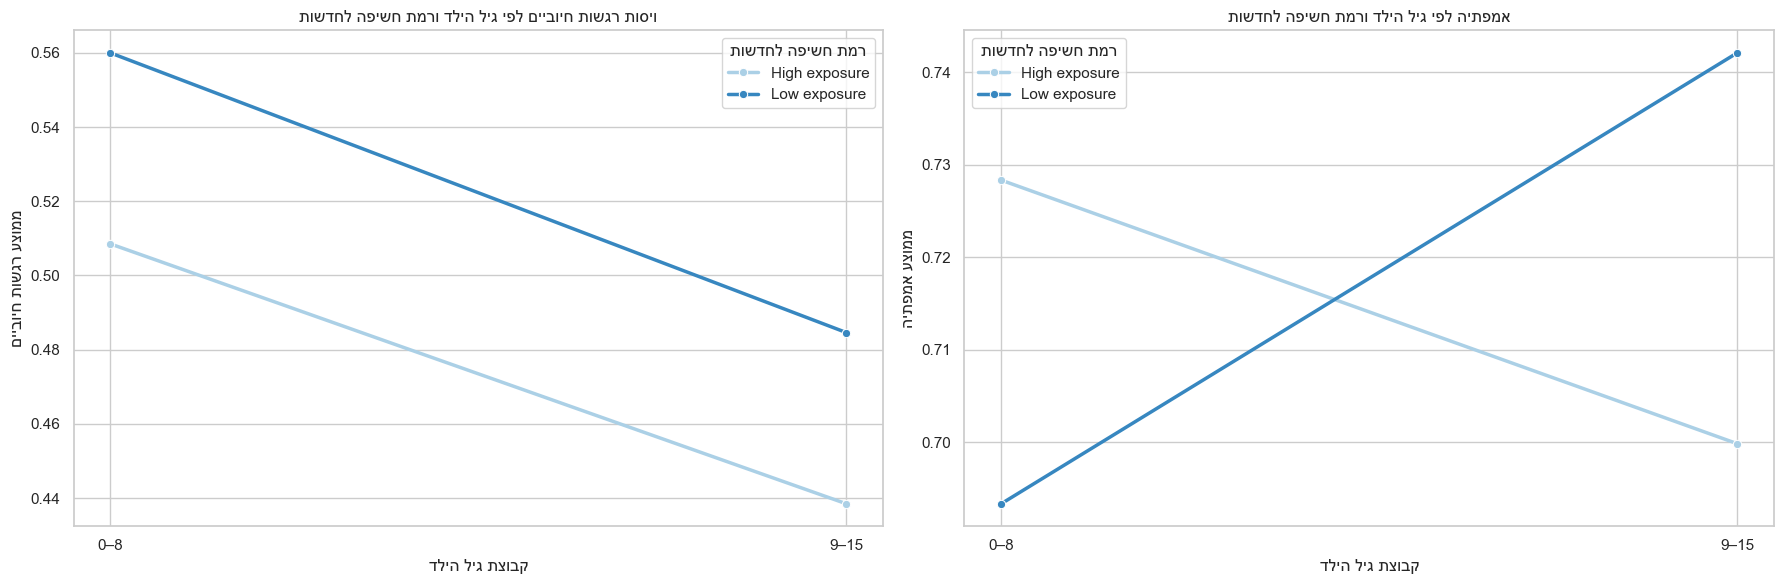

In [145]:
notna_df = df[df["news_freq_level"].notna() & df["child emotion regulation-positive"].notna() & df["child_empathy"].notna()].copy()
grouped = notna_df.groupby(["age_group_child_label", "news_freq_level"],observed=True).agg({"child emotion regulation-positive": "mean","child_empathy": "mean"}).reset_index()

palette_blues = sns.color_palette("Blues", n_colors=2)
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=True)

sns.lineplot(data=grouped,x="age_group_child_label",y="child emotion regulation-positive",hue="news_freq_level",marker="o",palette=palette_blues,ax=axes[0],linewidth=2.5)
axes[0].set_title(reshape_text("ויסות רגשות חיוביים לפי גיל הילד ורמת חשיפה לחדשות"))
axes[0].set_xlabel(reshape_text("קבוצת גיל הילד"))
axes[0].set_ylabel(reshape_text("ממוצע רגשות חיוביים"))
axes[0].legend(title=reshape_text("רמת חשיפה לחדשות"))

sns.lineplot(data=grouped,x="age_group_child_label",y="child_empathy",hue="news_freq_level",marker="o",palette=palette_blues,ax=axes[1],linewidth=2.5)
axes[1].set_title(reshape_text("אמפתיה לפי גיל הילד ורמת חשיפה לחדשות"))
axes[1].set_xlabel(reshape_text("קבוצת גיל הילד"))
axes[1].set_ylabel(reshape_text("ממוצע אמפתיה"))
axes[1].legend(title=reshape_text("רמת חשיפה לחדשות"))

plt.tight_layout()
plt.show()


<div dir="rtl" style="text-align:right; font-family:Arial; line-height:1.8;">

<table border="1" cellpadding="8" cellspacing="0" style="border-collapse: collapse; margin-bottom: 20px; width: 100%; text-align: center;">
<thead style="background-color: #f0f0f0;">
<tr>
<th>קבוצת גיל הילד</th>
<th>רגשות חיוביים</th>
<th>אמפתיה</th>
</tr>
</thead>
<tbody>
<tr>
<td><b>0–8</b></td>
<td>ילדים שהוריהם נחשפו יותר לחדשות הפגינו רמה נמוכה יותר של ממוצע וויסות רגשות חיוביים</td>
<td>ילדים שהוריהם נחשפו יותר לחדשות הפגינו רמת אמפתיה גבוהה יותר</td>
</tr>
<tr>
<td><b>9–15</b></td>
<td>ירידה חדה - ישנו הבדל בין רמות החשיפה, ילדים להורים שנחשפו יותר לחדשות הראו פחות רגשות חיוביים</td>
<td>הבדל משמעותי - גרפים הפוכים:חלה ירידה באמפתיה בקרב ילדהים להורים שנחשפו יותר לעומת לעומת עלייה באמפתיה בקרב ילדים שהוריהם נחשפו פחות.</td>
</tr>
</tbody>
</table>

</div>


<div dir='rtl'>
    <strong>מסקנות:</strong>
<br>
<strong>וויסות רגשות חיוביים:</strong> ילדים שהוריהם נחשפו פחות לחדשות הפגינו רמות גבוהות יותר של רגשות חיוביים – באופן עקבי בכל קבוצות הגיל.
<br>
<strong>אמפתיה:</strong> בגרף זה ניתן לראות כי בקרב ילדים צעירים, חשיפה גבוהה לחדשות מצד ההורים נקשרה לאמפתיה גבוהה יותר, אך בקרב ילדים בוגרים ההשפעה התהפכה: חשיפה נמוכה לחדשות הייתה קשורה לרמות אמפתיה גבוהות יותר.
</div>

<div dir="rtl">
<strong>מסקנות כוללות:</strong>
<br>
למרות שלא נמצא הבדל משמעותי ברמת הוויסות הרגשי בין הורים שנחשפו רבות לחדשות לבין אלו שנחשפו פחות, נמצא קשר ברור בין רמת החשיפה לבין תפיסת האווירה בבית – כאשר חשיפה גבוהה לחדשות נטתה להיות מלווה באווירה מתוחה יותר.
<br>
ההשפעה המורכבת של החשיפה לחדשות באה לידי ביטוי גם ברווחת הילד. ילדים להורים עם חשיפה גבוהה הציגו רמות נמוכות יותר של רגשות חיוביים, בעיקר בגילאים הבוגרים (9–15). באשר לאמפתיה, נמצא דפוס מעניין: בגיל הרך (0–8), חשיפה גבוהה של ההורה דווקא נקשרה לרמות אמפתיה גבוהות יותר בקרב הילדים. לעומת זאת, בגילאים הבוגרים, אותה חשיפה נקשרה לירידה ברמת האמפתיה של הילדים.

</div>


<h2 style="color: #345682">Appendices:</h2>

<div dir='rtl'>
במהלך העבודה השתמשנו בכלים הבאים:
<br>
1. chatGPT - עיצוב הגרפים, היכרות עם גרף ענן המילים ו-snaky, שימוש בספריית ערבית ועזרה ביצירת הפונקציה שהשמישה אותו על מנת להפוך את הכתב, עיצוב כללי של הפרוייקט וכתיבה ב-HTML. 
<br>
2. pandas - למדנו כיצד עובדים עם דאטא שיש בו ערכים חסרים, התעמקות עם פונקציות שלא היכרנו והצאט עזר לנו במציאת דרך ביצוע (דוג-replace, pivot).
<br>
3. google - חיפשנו אמירות מחקריות שתומכות בממצאים שלנו מבחינה פסיכולוגית (לעיתים גם נעזרנו בצ'אט).
</div>